# Machine Learning Classification with Iris Dataset

**What I am learning:**
- How to load and explore datasets
- How to prepare data for machine learning
- How to train and evaluate classification models
- How to compare different algorithms

## Step 1: Import Required Libraries

In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

In [4]:
# Load dataset from CSV
df = pd.read_csv("iris.data.csv", header=None)

# Add column names
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully
Shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Step 2: Understanding Key ML Concepts

Before we start coding, let's understand some important concepts:

 **Features**
Features are the input variables (measurements, attributes) that we use to make predictions. In the Iris dataset, features are:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

 **Labels (or Target)**
Labels are the output we want to predict. For Iris, the labels are the flower species:
- Setosa
- Versicolor
- Virginica

**Classification**
Classification is a supervised learning task where we predict which category (class) a new sample belongs to, based on features.

**Train/Test Split**
We divide our data into:
- **Training Set**: Used to teach the model (70-80% of data)
- **Testing Set**: Used to evaluate how well the model works (20-30% of data)

**Model Training**
During training, the model learns patterns from the training data by adjusting its internal parameters.

 **Prediction**
Once trained, the model can predict the label for new, unseen data.

 **Accuracy**
Accuracy measures how many predictions were correct: (Correct Predictions / Total Predictions) × 100%

## Step 3: Load the Iris Dataset

The Iris dataset is a classic dataset in machine learning. It contains measurements of 150 iris flowers from 3 different species.

In [5]:
# Load the Iris dataset
iris = load_iris()

# Extract features and labels
X = iris.data  # Features (measurements)
y = iris.target  # Labels (species)

# Get feature names and target names
feature_names = iris.feature_names
target_names = iris.target_names

print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

✓ Dataset loaded successfully!

Dataset shape: (150, 4)
Number of samples: 150
Number of features: 4


## Step 4: Explore the Dataset

Let's understand what our data looks like.

In [6]:
# Display feature names
print(" Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

print("\n Target Classes (Iris Species):")
for i, name in enumerate(target_names):
    print(f"  {i}. {name}")

print(f"\n Class Distribution:")
for i, name in enumerate(target_names):
    count = np.sum(y == i)
    print(f"  {name}: {count} samples")

 Feature Names:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)

 Target Classes (Iris Species):
  0. setosa
  1. versicolor
  2. virginica

 Class Distribution:
  setosa: 50 samples
  versicolor: 50 samples
  virginica: 50 samples


In [7]:
# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['Species'] = pd.Categorical.from_codes(y, target_names)

print("First 10 rows of the dataset:")
print(df.head(10))

print("\nDataset Summary Statistics:")
print(df.describe())

First 10 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  s

## Step 5: Visualize the Dataset

Visualizations help us understand the data better!

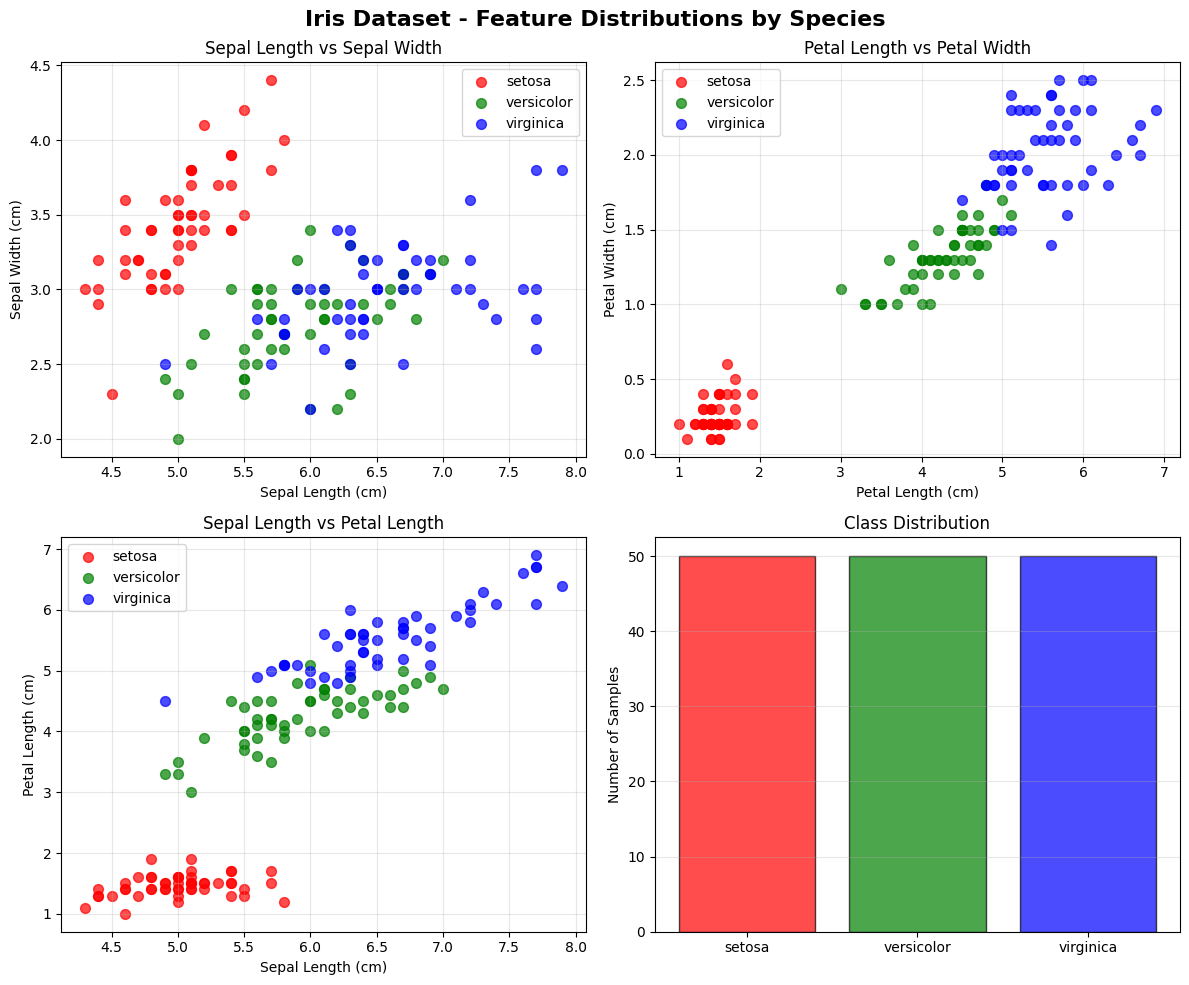

 Visualization complete! We can see that different species have different feature values.


In [8]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Iris Dataset - Feature Distributions by Species', fontsize=16, fontweight='bold')

# Colors for each species
colors = ['red', 'green', 'blue']
labels = target_names

# Plot 1: Sepal Length vs Sepal Width
ax = axes[0, 0]
for i, color, label in zip(range(3), colors, labels):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], c=color, label=label, s=50, alpha=0.7)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Sepal Length vs Sepal Width')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Petal Length vs Petal Width
ax = axes[0, 1]
for i, color, label in zip(range(3), colors, labels):
    mask = y == i
    ax.scatter(X[mask, 2], X[mask, 3], c=color, label=label, s=50, alpha=0.7)
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Petal Length vs Petal Width')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Sepal Length vs Petal Length
ax = axes[1, 0]
for i, color, label in zip(range(3), colors, labels):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 2], c=color, label=label, s=50, alpha=0.7)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_title('Sepal Length vs Petal Length')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Class Distribution
ax = axes[1, 1]
counts = [np.sum(y == i) for i in range(3)]
ax.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Visualization complete! We can see that different species have different feature values.")

## Step 6: Split Data into Training and Testing Sets

Now we'll split our data:
- **80% for training** - the model learns from this
- **20% for testing** - we evaluate the model on this unseen data

**Why?** This helps us see if the model can generalize to new data (avoid overfitting).

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # Use 20% for testing
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution
)

print("✓ Data split complete!")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
for i, name in enumerate(target_names):
    count = np.sum(y_train == i)
    print(f"  {name}: {count} samples")
print(f"\nTesting set class distribution:")
for i, name in enumerate(target_names):
    count = np.sum(y_test == i)
    print(f"  {name}: {count} samples")

✓ Data split complete!

Training set size: 120 samples
Testing set size: 30 samples

Training set class distribution:
  setosa: 40 samples
  versicolor: 40 samples
  virginica: 40 samples

Testing set class distribution:
  setosa: 10 samples
  versicolor: 10 samples
  virginica: 10 samples


## Step 7: Train Classification Models

We'll train three different classifiers and compare their performance:

### 1️⃣ **K-Nearest Neighbors (KNN)**
- Simple algorithm that classifies a point based on its k nearest neighbors
- Fast and intuitive

### 2️⃣ **Logistic Regression**
- Despite the name, it's a classification algorithm
- Finds a decision boundary to separate classes
- Fast and interpretable

### 3️⃣ **Decision Tree**
- Creates a tree-like decision structure
- Easy to understand and visualize
- Can capture non-linear relationships

In [10]:
# Initialize classifiers
# 1. K-Nearest Neighbors with k=3
knn = KNeighborsClassifier(n_neighbors=3)

# 2. Logistic Regression
log_reg = LogisticRegression(max_iter=200, random_state=42)

# 3. Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)

# Train all models
print("🎓 Training models...\n")

knn.fit(X_train, y_train)
print("✓ K-Nearest Neighbors trained!")

log_reg.fit(X_train, y_train)
print("✓ Logistic Regression trained!")

decision_tree.fit(X_train, y_train)
print("✓ Decision Tree trained!")

print("\n All models trained successfully!")

🎓 Training models...

✓ K-Nearest Neighbors trained!
✓ Logistic Regression trained!
✓ Decision Tree trained!

 All models trained successfully!


## Step 8: Make Predictions

Now let's use our trained models to make predictions on the test set.

In [11]:
# Make predictions on the test set
y_pred_knn = knn.predict(X_test)
y_pred_log_reg = log_reg.predict(X_test)
y_pred_tree = decision_tree.predict(X_test)

print(" Predictions Made!\n")
print("First 10 test samples:")
print(f"\n{'Sample':<8} {'Actual':<15} {'KNN':<15} {'Log Reg':<15} {'Tree':<15}")
print("-" * 70)

for i in range(10):
    actual = target_names[y_test[i]]
    pred_knn = target_names[y_pred_knn[i]]
    pred_log = target_names[y_pred_log_reg[i]]
    pred_tree = target_names[y_pred_tree[i]]
    print(f"{i+1:<8} {actual:<15} {pred_knn:<15} {pred_log:<15} {pred_tree:<15}")

 Predictions Made!

First 10 test samples:

Sample   Actual          KNN             Log Reg         Tree           
----------------------------------------------------------------------
1        setosa          setosa          setosa          setosa         
2        virginica       virginica       virginica       virginica      
3        versicolor      versicolor      versicolor      versicolor     
4        versicolor      versicolor      versicolor      versicolor     
5        setosa          setosa          setosa          setosa         
6        versicolor      versicolor      versicolor      versicolor     
7        setosa          setosa          setosa          setosa         
8        setosa          setosa          setosa          setosa         
9        virginica       virginica       virginica       virginica      
10       versicolor      versicolor      versicolor      versicolor     


## Step 9: Calculate Accuracy

Accuracy tells us what percentage of our predictions were correct.

In [12]:
# Calculate accuracies
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(" Model Accuracies on Test Set:\n")
print(f"K-Nearest Neighbors:   {accuracy_knn:.2%}")
print(f"Logistic Regression:   {accuracy_log_reg:.2%}")
print(f"Decision Tree:         {accuracy_tree:.2%}")

# Find the best model
accuracies = {
    'KNN': accuracy_knn,
    'Logistic Regression': accuracy_log_reg,
    'Decision Tree': accuracy_tree
}

best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print(f"\n Best Model: {best_model} with accuracy {best_accuracy:.2%}")

 Model Accuracies on Test Set:

K-Nearest Neighbors:   100.00%
Logistic Regression:   96.67%
Decision Tree:         93.33%

 Best Model: KNN with accuracy 100.00%


## Step 10: Visualize Accuracy Comparison

Let's compare the models visually.

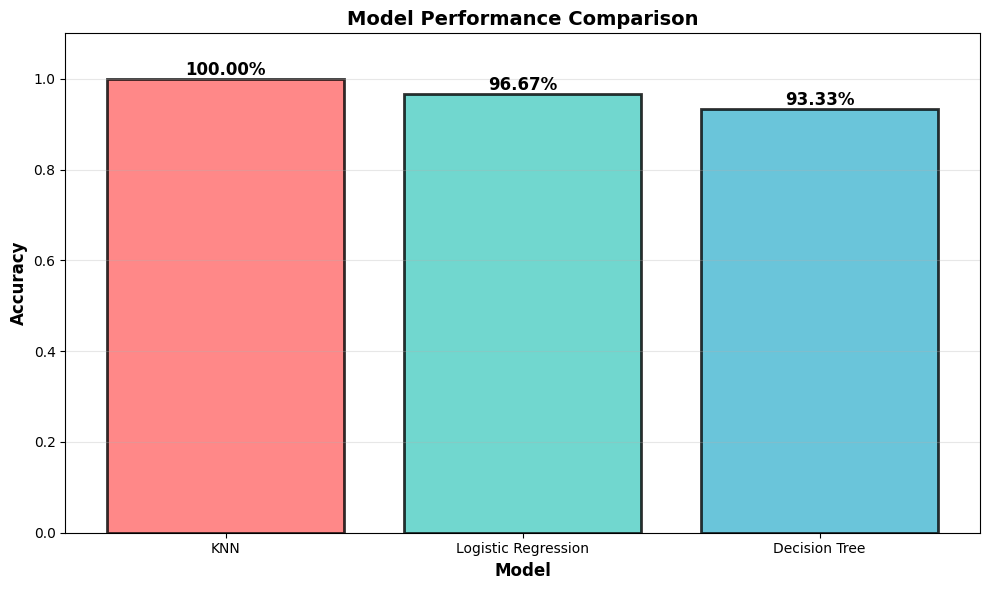

✓ Accuracy comparison chart created!


In [13]:
# Create a bar chart comparing accuracies
fig, ax = plt.subplots(figsize=(10, 6))

models = list(accuracies.keys())
scores = list(accuracies.values())
colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax.bar(models, scores, color=colors_models, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Accuracy comparison chart created!")

## Step 11: Detailed Model Evaluation - KNN

Let's perform detailed evaluation of our best models using classification reports and confusion matrices.

In [14]:
print("="*70)
print("K-NEAREST NEIGHBORS CLASSIFIER")
print("="*70)

print("\n Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

print("\n Confusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)
print("\nConfusion Matrix Explanation:")
print("- Rows represent actual classes")
print("- Columns represent predicted classes")
print("- Diagonal values (correctly classified) should be high")

K-NEAREST NEIGHBORS CLASSIFIER

 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


 Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Confusion Matrix Explanation:
- Rows represent actual classes
- Columns represent predicted classes
- Diagonal values (correctly classified) should be high


## Step 12: Detailed Model Evaluation - Logistic Regression

In [15]:

print("LOGISTIC REGRESSION CLASSIFIER")


print("\n Classification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=target_names))

print("\n Confusion Matrix:")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print(cm_log_reg)

LOGISTIC REGRESSION CLASSIFIER

 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


 Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## Step 13: Detailed Model Evaluation - Decision Tree

In [16]:
print("="*70)
print("DECISION TREE CLASSIFIER")
print("="*70)

print("\n Classification Report:")
print(classification_report(y_test, y_pred_tree, target_names=target_names))

print("\n Confusion Matrix:")
cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)

DECISION TREE CLASSIFIER

 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


 Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


## Step 14: Visualize Confusion Matrices

Confusion matrices help us understand where our models make mistakes.

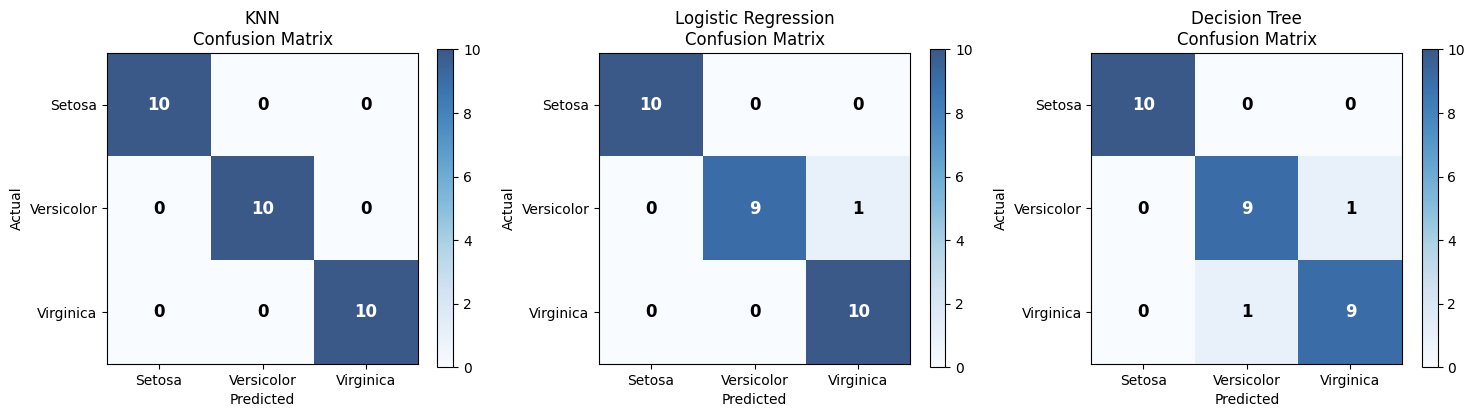

 Confusion matrices visualized!


In [17]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

confusion_matrices = [cm_knn, cm_log_reg, cm_tree]
model_names = ['KNN', 'Logistic Regression', 'Decision Tree']

for idx, (cm, model_name) in enumerate(zip(confusion_matrices, model_names)):
    ax = axes[idx]
    
    # Create heatmap
    im = ax.imshow(cm, cmap='Blues', alpha=0.8)
    
    # Set labels
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}\nConfusion Matrix')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
    ax.set_yticklabels(['Setosa', 'Versicolor', 'Virginica'])
    
    # Add text annotations
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max() / 2 else "black",
                          fontsize=12, fontweight='bold')
    
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(" Confusion matrices visualized!")

## Step 15: Test with Custom Data

Let's make predictions on some custom examples to see how our models work!

In [18]:
# Create custom samples
# Example 1: A Setosa-like flower
sample_1 = [[5.1, 3.5, 1.4, 0.2]]

# Example 2: A Versicolor-like flower
sample_2 = [[5.9, 3.0, 4.2, 1.5]]

# Example 3: A Virginica-like flower
sample_3 = [[6.7, 3.0, 5.2, 2.3]]

custom_samples = {
    'Sample 1 (Likely Setosa)': sample_1,
    'Sample 2 (Likely Versicolor)': sample_2,
    'Sample 3 (Likely Virginica)': sample_3
}

print("\n🔮 Predictions on Custom Samples:\n")

for sample_name, sample_data in custom_samples.items():
    print(f"\n{sample_name}")
    print(f"Features: Sepal Length={sample_data[0][0]}, Sepal Width={sample_data[0][1]}, "
          f"Petal Length={sample_data[0][2]}, Petal Width={sample_data[0][3]}")
    
    pred_knn = target_names[knn.predict(sample_data)[0]]
    pred_log = target_names[log_reg.predict(sample_data)[0]]
    pred_tree = target_names[decision_tree.predict(sample_data)[0]]
    
    print(f"  KNN prediction: {pred_knn}")
    print(f"  Logistic Regression prediction: {pred_log}")
    print(f"  Decision Tree prediction: {pred_tree}")


🔮 Predictions on Custom Samples:


Sample 1 (Likely Setosa)
Features: Sepal Length=5.1, Sepal Width=3.5, Petal Length=1.4, Petal Width=0.2
  KNN prediction: setosa
  Logistic Regression prediction: setosa
  Decision Tree prediction: setosa

Sample 2 (Likely Versicolor)
Features: Sepal Length=5.9, Sepal Width=3.0, Petal Length=4.2, Petal Width=1.5
  KNN prediction: versicolor
  Logistic Regression prediction: versicolor
  Decision Tree prediction: versicolor

Sample 3 (Likely Virginica)
Features: Sepal Length=6.7, Sepal Width=3.0, Petal Length=5.2, Petal Width=2.3
  KNN prediction: virginica
  Logistic Regression prediction: virginica
  Decision Tree prediction: virginica


## Step 16: Key Takeaways and Learning Summary

###  What We Learned

#### 1. **Data Preparation** 
   - Loaded and explored the Iris dataset
   - Understood features (measurements) and labels (species)
   - Split data into training (80%) and testing (20%) sets
   - This prevents overfitting and tests generalization

#### 2. **Model Training** 
   - Trained three different classifiers
   - Each algorithm has different approaches:
     - **KNN**: Simple, instance-based learning
     - **Logistic Regression**: Linear decision boundaries
     - **Decision Tree**: Tree-based decision making

#### 3. **Model Evaluation** 
   - Used **accuracy** to measure overall performance
   - Used **classification report** to see precision, recall, and F1-score per class
   - Used **confusion matrix** to understand prediction errors

#### 4. **Observations** 
   - All three models achieved high accuracy on the Iris dataset
   - The Iris dataset is relatively easy to classify (well-separated classes)
   - Different models may have different strengths:
     - KNN: Good baseline, sensitive to data scale
     - Logistic Regression: Fast, interpretable
     - Decision Tree: Easy to visualize and understand

#### 5. **Important Concepts** 
   - **Supervised Learning**: Learning from labeled data
   - **Classification**: Predicting categories/classes
   - **Train/Test Split**: Avoiding overfitting through validation
   - **Accuracy**: Proportion of correct predictions
   - **Confusion Matrix**: Understanding types of errors

## Step 17: Next Steps to Improve This Models

###  Ways to Enhance ML Skills

#### **1. Advanced Evaluation Techniques**
   - Cross-validation: Divide data into multiple folds for more robust evaluation
   - Learn about: `cross_val_score()`, `cross_validate()`

#### **2. Hyperparameter Tuning**
   - Optimize model parameters (e.g., k in KNN, max_depth in Decision Tree)
   - Techniques: Grid Search, Random Search, Bayesian Optimization
   - Learn about: `GridSearchCV`, `RandomizedSearchCV`

#### **3. Data Preprocessing**
   - Feature scaling (StandardScaler, MinMaxScaler)
   - Handle missing values
   - Deal with categorical features

#### **4. More Algorithms to Explore**
   - Support Vector Machines (SVM)
   - Random Forests (ensemble of decision trees)
   - Gradient Boosting (XGBoost, LightGBM)
   - Neural Networks

#### **5. Imbalanced Data Handling**
   - Use SMOTE for oversampling minority classes
   - Adjust class weights
   - Use appropriate metrics (F1-score, AUC-ROC)

#### **6. Real-World Projects**
   - Find datasets on Kaggle, UCI ML Repository
   - Start with small projects, gradually increase complexity
   - Practice building end-to-end pipelines

#### **7. Deep Learning**
   - Once comfortable with traditional ML, explore:
   - TensorFlow/Keras
   - PyTorch
   - Neural Networks for image, text, and sequential data

###  Recommended Learning Resources
   - Scikit-learn Documentation
   - Andrew Ng's Machine Learning Course
   - Fast.ai Practical Deep Learning
   - Kaggle Competitions and Datasets

## Summary

In this notebook, I:
-  Loaded and explored the Iris dataset
-  Visualized data patterns
-  Split data into training and testing sets
-  Trained three different classification algorithms
-  Evaluated model performance using accuracy, classification reports, and confusion matrices
-  Made predictions on new data
-  Compared different models